In [ ]:
            # --------SelectBest-------#
# SelectKBest method is a filter-based feature selection technique.
# Select the top k most important features based on a statistical test.
# SelectKBest selects the best k features according to a scoring function.

# Process
    # Calculate a score for each feature
    # Rank the features
    # Select the top k features

In [ ]:
# Basic Syntax
# from sklearn.feature_selection import SelectKBest
# from sklearn.feature_selection import score_function
# selector = SelectKBest(score_func=score_function, k=number_of_features) 
# score_func=Statistical test used to rank features

In [ ]:
# Common Score Function

## Chi-Square Test:
# Used for:
    # Categorical features
    # Classification problems
    # from sklearn.feature_selection import chi2
## ANOVA F-test:
# Used for:
    # Numerical features
    # Classification 
    # from sklearn.feature_selection import f_classif
## Correlation:
# Used for:
    # Feature Numeric 
    # Target Numeric
## F-Test for Regression
    # Regression Problem
    # from sklearn.feature_selection import f_regression

In [ ]:
# Import Required Libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

In [ ]:
# Skip all warnings
warnings.filterwarnings('ignore')

In [ ]:
# Import dataset
Wine_Data=pd.read_csv('wine_data.csv')

In [6]:
# Set column name
Wine_Data.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

In [ ]:
# Show the dataset
Wine_Data.sample(3)

# Input features are numerical and classification problem so use ANOVA test

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
119,2,11.45,2.40,2.42,20.0,96,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625
59,2,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680
112,2,11.41,0.74,2.50,21.0,88,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434


In [8]:
# Extract input and target feature
X=Wine_Data.drop(columns='Class label', axis=1)
y=Wine_Data['Class label']

# Split the dataset into train and test set
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=2
)

In [ ]:
# Select the best 5 feature
selector=SelectKBest(score_func=f_classif, k=5)
selector.fit_transform(X_train, y_train)

Index(['Alcohol', 'Flavanoids', 'Color intensity',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

In [17]:
# Show the top 5 best feature
X_train.columns[selector.get_support()]

Index(['Alcohol', 'Flavanoids', 'Color intensity',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

In [ ]:
# Show the score of each feature
selector.scores_

array([105.5973916 ,  39.17506827,   8.77242403,  27.60640225,
        10.10710044,  70.29105572, 165.24542277,  19.16907116,
        25.94552298, 102.37151601,  73.48226718, 125.94185572,
       168.82879784])

In [3]:
# Another code example for SelectBest Technique
df = pd.read_csv('diabetes.csv')

In [4]:
# Show the shape of the dataset
df.shape

(768, 9)

In [6]:
# Show the structure of the dataset
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [5]:
# Basic information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
# The type of outcome target
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
# Create new Feature from BloodPressure  column
df['BloodPressureSquare'] = np.square(df['BloodPressure'])
df['BloodPressureCube'] = df['BloodPressure']**3
df['BloodPressureSqrt'] = np.sqrt(df['BloodPressure'])

In [9]:
# Create new Feature from Glucode  column
df['GlucoseSquare'] = np.square(df['Glucose'])
df['GlucoseCube'] = df['Glucose']**3
df['GlucoseSqrt'] = np.sqrt(df['Glucose'])

In [10]:
# Create new column from AgeBMI and Bloodpressure
df['GlucoseBloodPressure'] = df['BloodPressure'] * df['Glucose']
df['AgeBMI'] = df['Age'] * df['BMI']

In [11]:
# Again show the dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BloodPressureSquare,BloodPressureCube,BloodPressureSqrt,GlucoseSquare,GlucoseCube,GlucoseSqrt,GlucoseBloodPressure,AgeBMI
0,6,148,72,35,0,33.6,0.627,50,1,5184,373248,8.485281,21904,3241792,12.165525,10656,1680.0
1,1,85,66,29,0,26.6,0.351,31,0,4356,287496,8.124038,7225,614125,9.219544,5610,824.6
2,8,183,64,0,0,23.3,0.672,32,1,4096,262144,8.000000,33489,6128487,13.527749,11712,745.6
3,1,89,66,23,94,28.1,0.167,21,0,4356,287496,8.124038,7921,704969,9.433981,5874,590.1
4,0,137,40,35,168,43.1,2.288,33,1,1600,64000,6.324555,18769,2571353,11.704700,5480,1422.3


In [12]:
# Extract Numerical Feature
numerical_feature_columns = list(df._get_numeric_data().columns)
numerical_feature_columns

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome',
 'BloodPressureSquare',
 'BloodPressureCube',
 'BloodPressureSqrt',
 'GlucoseSquare',
 'GlucoseCube',
 'GlucoseSqrt',
 'GlucoseBloodPressure',
 'AgeBMI']

<Axes: >

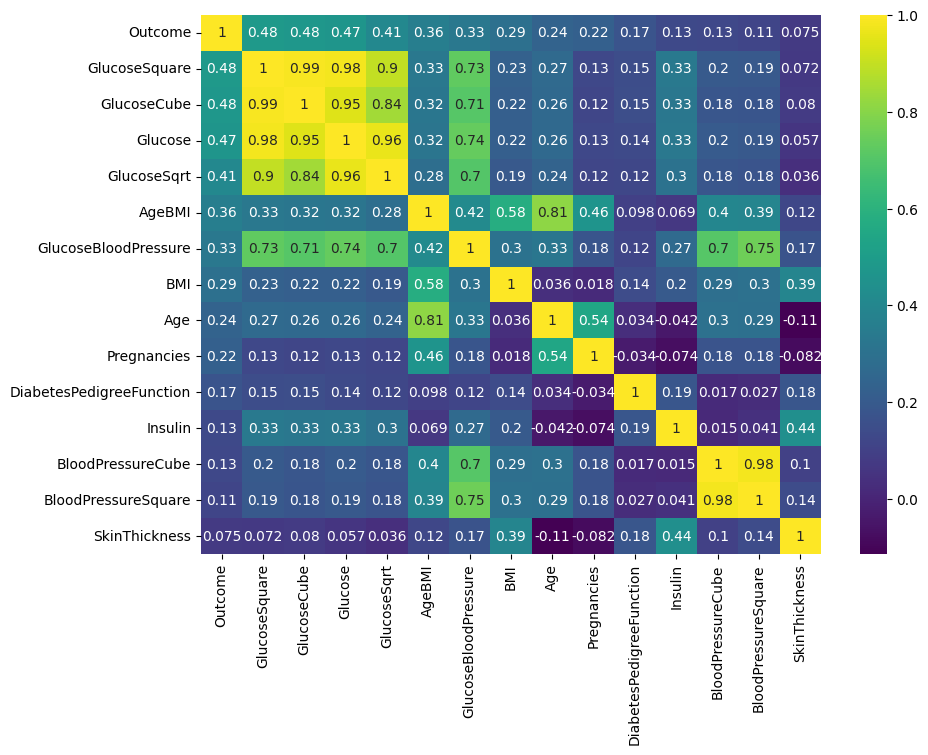

In [ ]:
# Draw heatmap to show the correlation among different features
target='Outcome'
k = 15 #number of variables for heatmap
num_df = df[numerical_feature_columns]
corr_matrix = num_df.corr()
target_corr = corr_matrix[target]
top_features = target_corr.nlargest(k)
cols = top_features.index
cm = df[cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, cmap = 'viridis')

In [17]:
# Extract target and input feature
X = df.loc[:, df.columns != target]
y = df.loc[:, df.columns == target]

In [18]:
# Show the shape of the target and input feature
X.shape
y.shape

(768, 1)

In [19]:
# Split the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=2)

In [63]:
# Create Logisticregresstion object
clf_lr=LogisticRegression(max_iter=1000)
# Create a baseline model for logistic regresssion
clf_lr.fit(X_train, y_train)
# Evaluate the model
y_pred=clf_lr.predict(X_test)
# Findout the accuracy
print('Accuracy Score of Base Model:', accuracy_score(y_test, y_pred))
print('F1 Score of Base Model:', f1_score(y_test, y_pred))

Accuracy Score of Base Model: 0.7467532467532467
F1 Score of Base Model: 0.5517241379310345


In [62]:
# Now perform feature selection

# Create SelectBest Object with ANOVA function_Score
select_feature=SelectKBest(f_classif, k=8)
# Fit the selection model with X_train and Y-train
select_feature.fit(X_train, y_train)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...0021060F94C20>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",8


In [48]:
# Create dataframe to show the score
select_feature_df=pd.DataFrame(
    {'Feature': list(X_train.columns),
     'Scores':select_feature.scores_ }
)
select_feature_df.sort_values(by='Scores', ascending=False)

,Feature,Scores
11,GlucoseSquare,197.522462
12,GlucoseCube,187.863437
1,Glucose,187.321141
13,GlucoseSqrt,144.740374
15,AgeBMI,89.406150
14,GlucoseBloodPressure,80.255392
5,BMI,56.639076
7,Age,38.814937
0,Pregnancies,35.479305
6,DiabetesPedigreeFunction,20.185184


In [49]:
# Now transform the feature
X_train_tf=select_feature.transform(X_train)
X_test_tf=select_feature.transform(X_test)

In [50]:
# Show x_train
X_train_tf[:3]

array([[1.24000000e+02, 2.78000000e+01, 3.00000000e+01, 1.53760000e+04,
        1.90662400e+06, 1.11355287e+01, 9.17600000e+03, 8.34000000e+02],
       [9.50000000e+01, 3.50000000e+01, 4.30000000e+01, 9.02500000e+03,
        8.57375000e+05, 9.74679434e+00, 7.79000000e+03, 1.50500000e+03],
       [9.40000000e+01, 4.35000000e+01, 2.10000000e+01, 8.83600000e+03,
        8.30584000e+05, 9.69535971e+00, 6.58000000e+03, 9.13500000e+02]])

In [61]:
# Now perform LogisticRegression
clf_lr_tf=LogisticRegression(max_iter=1000)
clf_lr_tf.fit(X_train_tf,y_train)
y_pred_tf=clf_lr_tf.predict(X_test_tf)
print('The Accuracy Score of Best Selected Feature:', accuracy_score(y_test,y_pred_tf))

The Accuracy Score of Best Selected Feature: 0.7857142857142857


In [ ]:
# After Using SElectBest method Score improve

In [60]:
# Now perform Recursive Feature elimination
rfe=RFE(estimator=clf_lr, step=1)
rfe.fit(X_train, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",None
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [53]:
# Show the selected feature
selected_rfe_features=pd.DataFrame(
    {'Feature': list(X_train.columns),
     'Ranking': rfe.ranking_}
)
selected_rfe_features.sort_values(by='Ranking', ascending=False)

,Feature,Ranking
12,GlucoseCube,9
9,BloodPressureCube,8
14,GlucoseBloodPressure,7
11,GlucoseSquare,6
8,BloodPressureSquare,5
15,AgeBMI,4
2,BloodPressure,3
4,Insulin,2
7,Age,1
6,DiabetesPedigreeFunction,1


In [54]:
# Transform X_train and X_test
X_train_rtf=rfe.transform(X_train)
X_test_rtf=rfe.transform(X_test)

In [59]:
# Train the model and evaluate it
clf_lr_rtf=LogisticRegression(max_iter=1000)
clf_lr_rtf.fit(X_train_rtf, y_train)
y_pred_rtf=clf_lr_rtf.predict(X_test_rtf)
print('The accuracy score after RFE:', accuracy_score(y_test, y_pred_rtf))

The accuracy score after RFE: 0.7662337662337663


In [58]:

# Recursive feature elimination with cross validation

rfecv = RFECV(estimator=clf_lr, step=1, cv=5, scoring='accuracy')
rfecv = rfecv.fit(X_train, y_train)
print('Optimal number of features :', rfecv.n_features_)
print('Best features :', X_train.columns[rfecv.support_])

Optimal number of features : 6
Best features : Index(['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction',
       'BloodPressureSqrt', 'GlucoseSqrt'],
      dtype='object')


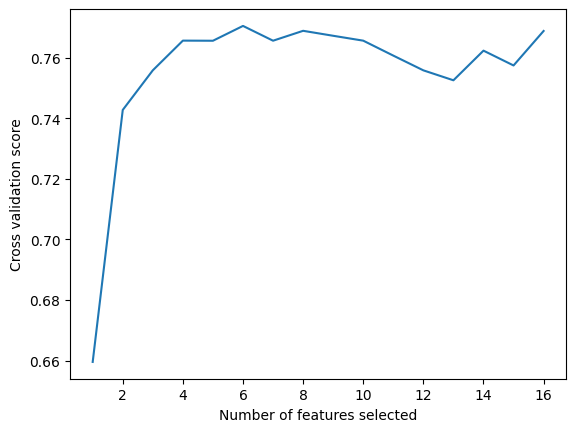

In [ ]:
# Plot the score
scores = rfecv.cv_results_['mean_test_score']
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score")
plt.plot(range(1, len(scores) + 1), scores)

plt.show()

In [69]:
# Transform the X_train and X_test
X_train_rfe_t=rfecv.transform(X_train)
X_test_rfe_t=rfecv.transform(X_test)

In [72]:
# Train the model and evaluate it
clf_lr_rfecv=LogisticRegression(max_iter=1000)
clf_lr_rfecv.fit(X_train_rfe_t, y_train)
y_pred_rfecv=clf_lr_rfecv.predict(X_test_rfe_t)
print('The accuracy score:', accuracy_score(y_pred_rfecv, y_test))

The accuracy score: 0.7662337662337663
